
# TensorFlow Learning Notebook

This notebook is a **hands-on guide to TensorFlow** with examples of the most used parts of the library.

It covers:
- installation and Jupyter setup
- tensors, variables, dtypes, shapes
- TensorFlow math and array operations
- `tf.data` pipelines
- automatic differentiation with `tf.GradientTape`
- building models with `tf.keras`
- layers, losses, optimizers, metrics, and callbacks
- training with `model.fit()`
- custom training loops
- saving and loading models
- `tf.function`
- CNN basics
- useful library inspection tools

**Note:** TensorFlow is a very large library, so this notebook shows the **most important and commonly used features** rather than literally every API entry.



## 1) Jupyter setup

Install TensorFlow and notebook tools:

```bash
pip install tensorflow numpy matplotlib pandas scikit-learn jupyter
jupyter notebook
```

If you use conda:

```bash
conda install numpy matplotlib pandas scikit-learn jupyter
pip install tensorflow
jupyter notebook
```

On Apple Silicon Macs, TensorFlow setup can differ depending on your environment.


In [1]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


/opt/homebrew/anaconda3/envs/mlenv/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow version: 2.19.0
NumPy version: 2.2.4
GPUs: []


## 2) What is TensorFlow?

In [2]:

# TensorFlow works with tensors, which are like multidimensional arrays.
scalar = tf.constant(5)
vector = tf.constant([1, 2, 3])
matrix = tf.constant([[1, 2], [3, 4]])
tensor3d = tf.constant([[[1], [2]], [[3], [4]]])

print("scalar:", scalar)
print("vector:", vector)
print("matrix:\n", matrix)
print("tensor3d:\n", tensor3d)


scalar: tf.Tensor(5, shape=(), dtype=int32)
vector: tf.Tensor([1 2 3], shape=(3,), dtype=int32)
matrix:
 tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
tensor3d:
 tf.Tensor(
[[[1]
  [2]]

 [[3]
  [4]]], shape=(2, 2, 1), dtype=int32)


## 3) Core tensor properties

In [3]:

x = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

print("Tensor:\n", x)
print("Shape:", x.shape)
print("Rank:", tf.rank(x).numpy())
print("Dtype:", x.dtype)
print("NumPy conversion:\n", x.numpy())


Tensor:
 tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)
Shape: (2, 3)
Rank: 2
Dtype: <dtype: 'float32'>
NumPy conversion:
 [[1. 2. 3.]
 [4. 5. 6.]]


## 4) Creating tensors

In [4]:

zeros = tf.zeros((2, 3))
ones = tf.ones((2, 3))
fill = tf.fill((2, 3), 9)
range_tensor = tf.range(0, 10, 2)
linspace_tensor = tf.linspace(0.0, 1.0, 5)
eye = tf.eye(3)
random_uniform = tf.random.uniform((2, 3), minval=0, maxval=1)
random_normal = tf.random.normal((2, 3), mean=0.0, stddev=1.0)

print("zeros:\n", zeros.numpy())
print("\nones:\n", ones.numpy())
print("\nfill:\n", fill.numpy())
print("\nrange:", range_tensor.numpy())
print("linspace:", linspace_tensor.numpy())
print("\neye:\n", eye.numpy())
print("\nrandom_uniform:\n", random_uniform.numpy())
print("\nrandom_normal:\n", random_normal.numpy())


zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]

ones:
 [[1. 1. 1.]
 [1. 1. 1.]]

fill:
 [[9 9 9]
 [9 9 9]]

range: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]

eye:
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

random_uniform:
 [[0.4614842  0.60737145 0.8336742 ]
 [0.05308092 0.5305035  0.37318885]]

random_normal:
 [[-1.3960193   1.3973814   0.96837807]
 [-1.3143629   1.8861759   0.9948451 ]]


## 5) Dtypes and casting

In [5]:

x = tf.constant([1, 2, 3], dtype=tf.int32)
y = tf.cast(x, tf.float32)

print("Original:", x, x.dtype)
print("Casted:", y, y.dtype)


Original: tf.Tensor([1 2 3], shape=(3,), dtype=int32) <dtype: 'int32'>
Casted: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32) <dtype: 'float32'>


## 6) Reshaping and dimension operations

In [6]:

x = tf.range(12)

reshaped = tf.reshape(x, (3, 4))
transposed = tf.transpose(reshaped)
expanded = tf.expand_dims(x, axis=0)
squeezed = tf.squeeze(tf.constant([[[1], [2], [3]]]))

print("Original:", x.numpy())
print("\nReshaped:\n", reshaped.numpy())
print("\nTransposed:\n", transposed.numpy())
print("\nExpanded dims shape:", expanded.shape)
print(expanded.numpy())
print("\nSqueezed:", squeezed.numpy())


Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]

Reshaped:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Transposed:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]

Expanded dims shape: (1, 12)
[[ 0  1  2  3  4  5  6  7  8  9 10 11]]

Squeezed: [1 2 3]


## 7) Indexing and slicing

In [7]:

x = tf.reshape(tf.range(1, 13), (3, 4))

print("x:\n", x.numpy())
print("\nFirst row:", x[0].numpy())
print("Last column:", x[:, -1].numpy())
print("Submatrix:\n", x[1:, 1:3].numpy())


x:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

First row: [1 2 3 4]
Last column: [ 4  8 12]
Submatrix:
 [[ 6  7]
 [10 11]]


## 8) Common math operations

In [8]:

a = tf.constant([1.0, 2.0, 3.0])
b = tf.constant([10.0, 20.0, 30.0])

print("add:", tf.add(a, b).numpy())
print("subtract:", tf.subtract(a, b).numpy())
print("multiply:", tf.multiply(a, b).numpy())
print("divide:", tf.divide(b, a).numpy())
print("square:", tf.square(a).numpy())
print("sqrt:", tf.sqrt(b).numpy())
print("exp:", tf.exp(a).numpy())
print("log:", tf.math.log(a).numpy())
print("sin:", tf.sin(a).numpy())
print("cos:", tf.cos(a).numpy())


add: [11. 22. 33.]
subtract: [ -9. -18. -27.]
multiply: [10. 40. 90.]
divide: [10. 10. 10.]
square: [1. 4. 9.]
sqrt: [3.1622777 4.472136  5.477226 ]
exp: [ 2.7182817  7.389056  20.085537 ]
log: [0.        0.6931472 1.0986123]
sin: [0.84147096 0.9092974  0.14112   ]
cos: [ 0.5403023  -0.41614684 -0.9899925 ]


## 9) Reductions and statistics

In [9]:

x = tf.constant([[1.0, 2.0], [3.0, 4.0]])

print("reduce_sum:", tf.reduce_sum(x).numpy())
print("reduce_mean:", tf.reduce_mean(x).numpy())
print("reduce_max:", tf.reduce_max(x).numpy())
print("reduce_min:", tf.reduce_min(x).numpy())
print("reduce_sum axis=0:", tf.reduce_sum(x, axis=0).numpy())
print("reduce_mean axis=1:", tf.reduce_mean(x, axis=1).numpy())
print("argmax axis=1:", tf.argmax(x, axis=1).numpy())
print("argmin axis=0:", tf.argmin(x, axis=0).numpy())


reduce_sum: 10.0
reduce_mean: 2.5
reduce_max: 4.0
reduce_min: 1.0
reduce_sum axis=0: [4. 6.]
reduce_mean axis=1: [1.5 3.5]
argmax axis=1: [1 1]
argmin axis=0: [0 0]


## 10) Matrix operations

In [10]:

A = tf.constant([[1.0, 2.0], [3.0, 4.0]])
B = tf.constant([[5.0, 6.0], [7.0, 8.0]])

print("matmul:\n", tf.matmul(A, B).numpy())
print("\ntranspose:\n", tf.transpose(A).numpy())
print("\ndeterminant:", tf.linalg.det(A).numpy())
print("\ninverse:\n", tf.linalg.inv(A).numpy())
print("\nnorm:", tf.norm(A).numpy())


matmul:
 [[19. 22.]
 [43. 50.]]

transpose:
 [[1. 3.]
 [2. 4.]]

determinant: -2.0

inverse:
 [[-2.0000002   1.0000001 ]
 [ 1.5000001  -0.50000006]]

norm: 5.477226


## 11) Broadcasting

In [11]:

matrix = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
vector = tf.constant([10.0, 20.0, 30.0])

print((matrix + vector).numpy())


[[11. 22. 33.]
 [14. 25. 36.]]


## 12) Variables

In [12]:

v = tf.Variable([1.0, 2.0, 3.0])

print("Before:", v.numpy())
v.assign([4.0, 5.0, 6.0])
print("After assign:", v.numpy())
v.assign_add([1.0, 1.0, 1.0])
print("After assign_add:", v.numpy())


Before: [1. 2. 3.]
After assign: [4. 5. 6.]
After assign_add: [5. 6. 7.]


## 13) Automatic differentiation with GradientTape

In [13]:

x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2 + 2*x + 1

grad = tape.gradient(y, x)
print("y =", y.numpy())
print("dy/dx =", grad.numpy())


y = 16.0
dy/dx = 8.0


In [14]:

# Gradient with respect to multiple variables
w = tf.Variable(2.0)
b = tf.Variable(1.0)
x = tf.constant(3.0)

with tf.GradientTape() as tape:
    y = w * x + b
    loss = (y - 10.0)**2

grads = tape.gradient(loss, [w, b])
print("loss:", loss.numpy())
print("dw:", grads[0].numpy())
print("db:", grads[1].numpy())


loss: 9.0
dw: -18.0
db: -6.0


## 14) tf.function

In [15]:

@tf.function
def my_function(x):
    return x * x + 1

x = tf.constant([1.0, 2.0, 3.0])
print("Result:", my_function(x).numpy())
print("Concrete TensorFlow function created with @tf.function")


Result: [ 2.  5. 10.]
Concrete TensorFlow function created with @tf.function


## 15) Loading a simple dataset

In [16]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Classes:", iris.target_names)


X_train shape: (120, 4)
X_test shape: (30, 4)
Classes: ['setosa' 'versicolor' 'virginica']


## 16) tf.data pipelines

In [17]:

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(X_train)).batch(16).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(16)

for features, labels in train_ds.take(1):
    print("Batch features shape:", features.shape)
    print("Batch labels shape:", labels.shape)


Batch features shape: (16, 4)
Batch labels shape: (16,)


2026-03-14 22:54:02.540967: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 17) Building a model with tf.keras.Sequential

In [18]:

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

## 18) Compile: losses, optimizers, metrics

In [19]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)
print("Model compiled.")


Model compiled.


## 19) Train with model.fit()

In [20]:

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    verbose=0
)

print("Training complete.")
print("History keys:", history.history.keys())


Training complete.
History keys: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## 20) Evaluate and predict

In [21]:

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

pred_probs = model.predict(X_test[:5], verbose=0)
pred_classes = np.argmax(pred_probs, axis=1)

print("\nPredicted probabilities:\n", pred_probs)
print("\nPredicted classes:", pred_classes)
print("True classes:", y_test[:5])


Test loss: 0.06686122715473175
Test accuracy: 1.0

Predicted probabilities:
 [[9.9873090e-01 1.2691384e-03 1.8139110e-09]
 [4.4799370e-05 2.0839529e-01 7.9155988e-01]
 [5.2493610e-03 9.9192667e-01 2.8239242e-03]
 [5.2603232e-03 9.9213612e-01 2.6035074e-03]
 [9.9906200e-01 9.3797391e-04 9.1904867e-10]]

Predicted classes: [0 2 1 1 0]
True classes: [0 2 1 1 0]


## 21) Plot training history

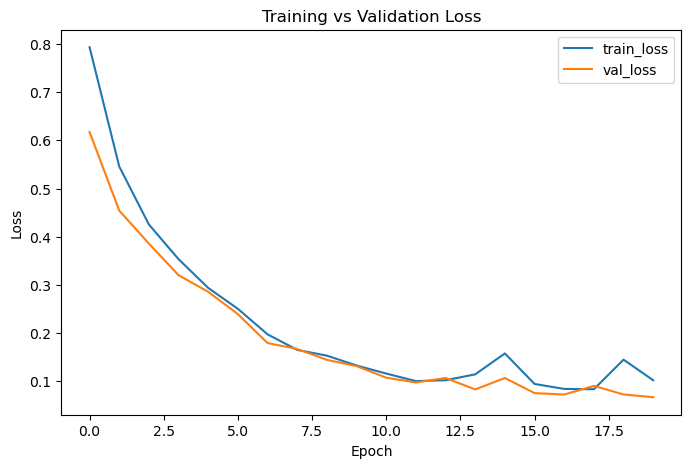

In [22]:

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


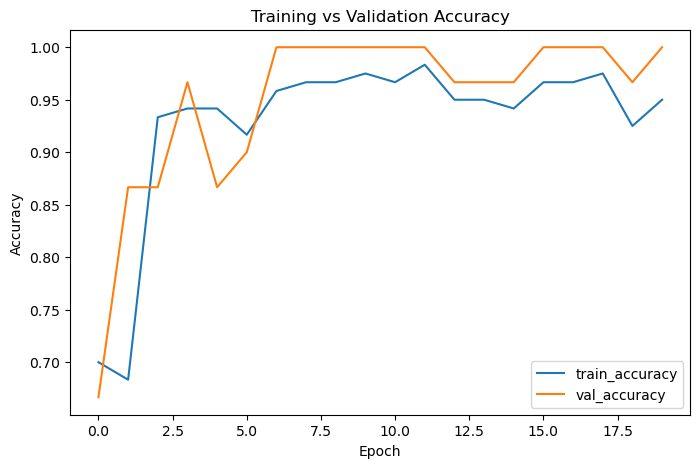

In [23]:

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


## 22) Frequently used layers

In [24]:

layers_examples = [
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.BatchNormalization(),
]

for layer in layers_examples:
    print(layer)


<Dense name=dense_3, built=False>
<Dropout name=dropout, built=True>
<BatchNormalization name=batch_normalization, built=False>


## 23) Functional API

In [25]:

inputs = tf.keras.Input(shape=(4,))
x = tf.keras.layers.Dense(32, activation="relu")(inputs)
x = tf.keras.layers.Dense(16, activation="relu")(x)
outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

functional_model = tf.keras.Model(inputs=inputs, outputs=outputs)
functional_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

## 24) Custom model subclassing

In [26]:

class SimpleClassifier(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(16, activation="relu")
        self.d2 = tf.keras.layers.Dense(16, activation="relu")
        self.out = tf.keras.layers.Dense(3, activation="softmax")

    def call(self, inputs):
        x = self.d1(inputs)
        x = self.d2(x)
        return self.out(x)

subclassed_model = SimpleClassifier()
subclassed_model(tf.constant(X_train[:2]))
print("Subclassed model ran successfully.")


Subclassed model ran successfully.


## 25) Callbacks

In [27]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

small_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

small_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

small_history = small_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    callbacks=callbacks,
    verbose=0
)

print("Training stopped after", len(small_history.history["loss"]), "epochs")


Training stopped after 30 epochs


## 26) Saving and loading models

In [28]:

from pathlib import Path

Path("saved_models").mkdir(exist_ok=True)
save_path = "saved_models/iris_tf_model.keras"

model.save(save_path)
loaded_model = tf.keras.models.load_model(save_path)

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=0)
print("Loaded model accuracy:", loaded_acc)
print("Saved to:", save_path)


Loaded model accuracy: 1.0
Saved to: saved_models/iris_tf_model.keras


## 27) Custom training loop

In [29]:

custom_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(3)
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(0.01)
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

for epoch in range(5):
    train_acc_metric.reset_state()
    for xb, yb in train_ds:
        with tf.GradientTape() as tape:
            logits = custom_model(xb, training=True)
            loss_value = loss_fn(yb, logits)
        grads = tape.gradient(loss_value, custom_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, custom_model.trainable_variables))
        train_acc_metric.update_state(yb, logits)

    print(f"Epoch {epoch+1}: loss={loss_value.numpy():.4f}, accuracy={train_acc_metric.result().numpy():.4f}")


Epoch 1: loss=1.5227, accuracy=0.3083
Epoch 2: loss=0.7763, accuracy=0.5333
Epoch 3: loss=0.5785, accuracy=0.6250
Epoch 4: loss=0.3946, accuracy=0.6917
Epoch 5: loss=0.6235, accuracy=0.6750


2026-03-14 22:54:25.253526: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-14 22:54:25.339014: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 28) CNN example on image-like data

In [30]:

# Dummy image batch: 8 grayscale images of size 28x28
dummy_images = tf.random.normal((8, 28, 28, 1))

cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, kernel_size=3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax")
])

cnn_output = cnn(dummy_images)
print("CNN output shape:", cnn_output.shape)
cnn.summary()


CNN output shape: (8, 10)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │        38,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,530 (170.04 KB)

 Trainable params: 43,530 (170.04 KB)

 Non-trainable params: 0 (0.00 B)

## 29) Useful TensorFlow modules

In [31]:

common_modules = {
    "Core tensors and math": ["tf.constant", "tf.Variable", "tf.cast", "tf.reshape", "tf.transpose", "tf.matmul"],
    "Math/statistics": ["tf.reduce_sum", "tf.reduce_mean", "tf.argmax", "tf.math.log", "tf.math.exp"],
    "Random": ["tf.random.uniform", "tf.random.normal", "tf.random.set_seed"],
    "Data pipelines": ["tf.data.Dataset.from_tensor_slices", "shuffle", "batch", "map", "prefetch"],
    "Autodiff": ["tf.GradientTape"],
    "Keras model building": ["tf.keras.Sequential", "tf.keras.Model", "tf.keras.Input"],
    "Layers": ["Dense", "Dropout", "BatchNormalization", "Conv2D", "MaxPooling2D", "Flatten", "LSTM", "Embedding"],
    "Optimizers": ["SGD", "Adam", "RMSprop"],
    "Losses": ["SparseCategoricalCrossentropy", "CategoricalCrossentropy", "MeanSquaredError", "BinaryCrossentropy"],
    "Metrics": ["Accuracy", "SparseCategoricalAccuracy", "Precision", "Recall"],
    "Callbacks": ["EarlyStopping", "ModelCheckpoint", "ReduceLROnPlateau", "TensorBoard"],
    "Saving": ["model.save", "tf.keras.models.load_model"],
    "Performance": ["tf.function", "tf.config", "tf.distribute.Strategy", "mixed_precision"],
}

for category, items in common_modules.items():
    print(f"\n{category}:")
    print(", ".join(items))



Core tensors and math:
tf.constant, tf.Variable, tf.cast, tf.reshape, tf.transpose, tf.matmul

Math/statistics:
tf.reduce_sum, tf.reduce_mean, tf.argmax, tf.math.log, tf.math.exp

Random:
tf.random.uniform, tf.random.normal, tf.random.set_seed

Data pipelines:
tf.data.Dataset.from_tensor_slices, shuffle, batch, map, prefetch

Autodiff:
tf.GradientTape

Keras model building:
tf.keras.Sequential, tf.keras.Model, tf.keras.Input

Layers:
Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D, Flatten, LSTM, Embedding

Optimizers:
SGD, Adam, RMSprop

Losses:
SparseCategoricalCrossentropy, CategoricalCrossentropy, MeanSquaredError, BinaryCrossentropy

Metrics:
Accuracy, SparseCategoricalAccuracy, Precision, Recall

Callbacks:
EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard

Saving:
model.save, tf.keras.models.load_model

Performance:
tf.function, tf.config, tf.distribute.Strategy, mixed_precision


## 30) Inspect library contents

In [32]:

print("Some public names in tf:")
public_tf_names = [name for name in dir(tf) if not name.startswith("_")]
print(public_tf_names[:200])
print("\nTotal shown:", len(public_tf_names))


Some public names in tf:
['AggregationMethod', 'Assert', 'CriticalSection', 'DType', 'DeviceSpec', 'GradientTape', 'Graph', 'IndexedSlices', 'IndexedSlicesSpec', 'Module', 'Operation', 'OptionalSpec', 'RaggedTensor', 'RaggedTensorSpec', 'RegisterGradient', 'SparseTensor', 'SparseTensorSpec', 'Tensor', 'TensorArray', 'TensorArraySpec', 'TensorShape', 'TensorSpec', 'TypeSpec', 'UnconnectedGradients', 'Variable', 'VariableAggregation', 'VariableSynchronization', 'abs', 'acos', 'acosh', 'add', 'add_n', 'approx_top_k', 'argmax', 'argmin', 'argsort', 'as_dtype', 'as_string', 'asin', 'asinh', 'assert_equal', 'assert_greater', 'assert_less', 'assert_rank', 'atan', 'atan2', 'atanh', 'audio', 'autodiff', 'autograph', 'batch_to_space', 'bfloat16', 'bitcast', 'bitwise', 'bool', 'boolean_mask', 'broadcast_dynamic_shape', 'broadcast_static_shape', 'broadcast_to', 'case', 'cast', 'check_pinned', 'clip_by_global_norm', 'clip_by_norm', 'clip_by_value', 'compat', 'complex', 'complex128', 'complex64', 'c

In [33]:

print("Some public names in tf.keras.layers:")
public_layer_names = [name for name in dir(tf.keras.layers) if not name.startswith("_")]
print(public_layer_names[:150])
print("\nTotal shown:", len(public_layer_names))


Some public names in tf.keras.layers:
['Activation', 'ActivityRegularization', 'AdaptiveAveragePooling1D', 'AdaptiveAveragePooling2D', 'AdaptiveAveragePooling3D', 'AdaptiveMaxPooling1D', 'AdaptiveMaxPooling2D', 'AdaptiveMaxPooling3D', 'Add', 'AdditiveAttention', 'AlphaDropout', 'Attention', 'AugMix', 'AutoContrast', 'Average', 'AveragePooling1D', 'AveragePooling2D', 'AveragePooling3D', 'AvgPool1D', 'AvgPool2D', 'AvgPool3D', 'BatchNormalization', 'Bidirectional', 'CategoryEncoding', 'CenterCrop', 'Concatenate', 'Conv1D', 'Conv1DTranspose', 'Conv2D', 'Conv2DTranspose', 'Conv3D', 'Conv3DTranspose', 'ConvLSTM1D', 'ConvLSTM2D', 'ConvLSTM3D', 'Convolution1D', 'Convolution1DTranspose', 'Convolution2D', 'Convolution2DTranspose', 'Convolution3D', 'Convolution3DTranspose', 'Cropping1D', 'Cropping2D', 'Cropping3D', 'CutMix', 'Dense', 'DepthwiseConv1D', 'DepthwiseConv2D', 'Discretization', 'Dot', 'Dropout', 'ELU', 'EinsumDense', 'Embedding', 'Equalization', 'Flatten', 'FlaxLayer', 'GRU', 'GRUCell'

## 31) Optional features you will likely use later

In [34]:

later_topics = [
    "TensorBoard for experiment tracking",
    "ModelCheckpoint for saving best weights",
    "tf.distribute.Strategy for multi-GPU / multi-worker training",
    "mixed precision for faster GPU training",
    "transfer learning with pretrained models",
    "TensorFlow Lite for mobile / edge deployment",
    "SavedModel export for serving",
]

for item in later_topics:
    print("-", item)


- TensorBoard for experiment tracking
- ModelCheckpoint for saving best weights
- tf.distribute.Strategy for multi-GPU / multi-worker training
- mixed precision for faster GPU training
- transfer learning with pretrained models
- TensorFlow Lite for mobile / edge deployment
- SavedModel export for serving



## 32) Practice exercises

1. Create a tensor of shape `(3, 4)` filled with ones.
2. Reshape a tensor from shape `(12,)` to `(4, 3)`.
3. Compute the gradient of `y = x^3` at `x = 2`.
4. Build a `Sequential` model with 2 hidden layers.
5. Train a classifier on the Iris dataset and compare train/test accuracy.
6. Add `Dropout` and `EarlyStopping` to the model.
7. Save the model and reload it.
8. Create a CNN and verify its output shape on dummy images.



## 33) Summary

You now have a notebook that introduces the main TensorFlow workflow:

- tensors and variables
- TensorFlow ops and math
- gradients with `tf.GradientTape`
- datasets with `tf.data`
- models with `tf.keras`
- training, evaluation, prediction
- callbacks, saving/loading, and custom training loops

This is the core path most TensorFlow projects follow.
